# Day 06 — Exploratory Data Analysis
**Member 4** | Goal: Visualise all key patterns before modelling

## Objectives
- Yield trends over time per district
- Weather variable distributions and seasonality
- Correlation between weather features and yield
- Risk score patterns across years and districts

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import sys
sys.path.append('../src')
from config import DB_PATH

sns.set_theme(style='whitegrid', font_scale=1.1)
con = duckdb.connect(DB_PATH)
print('Connected ✓')

Connected ✓


## 1. Yield Trends per District

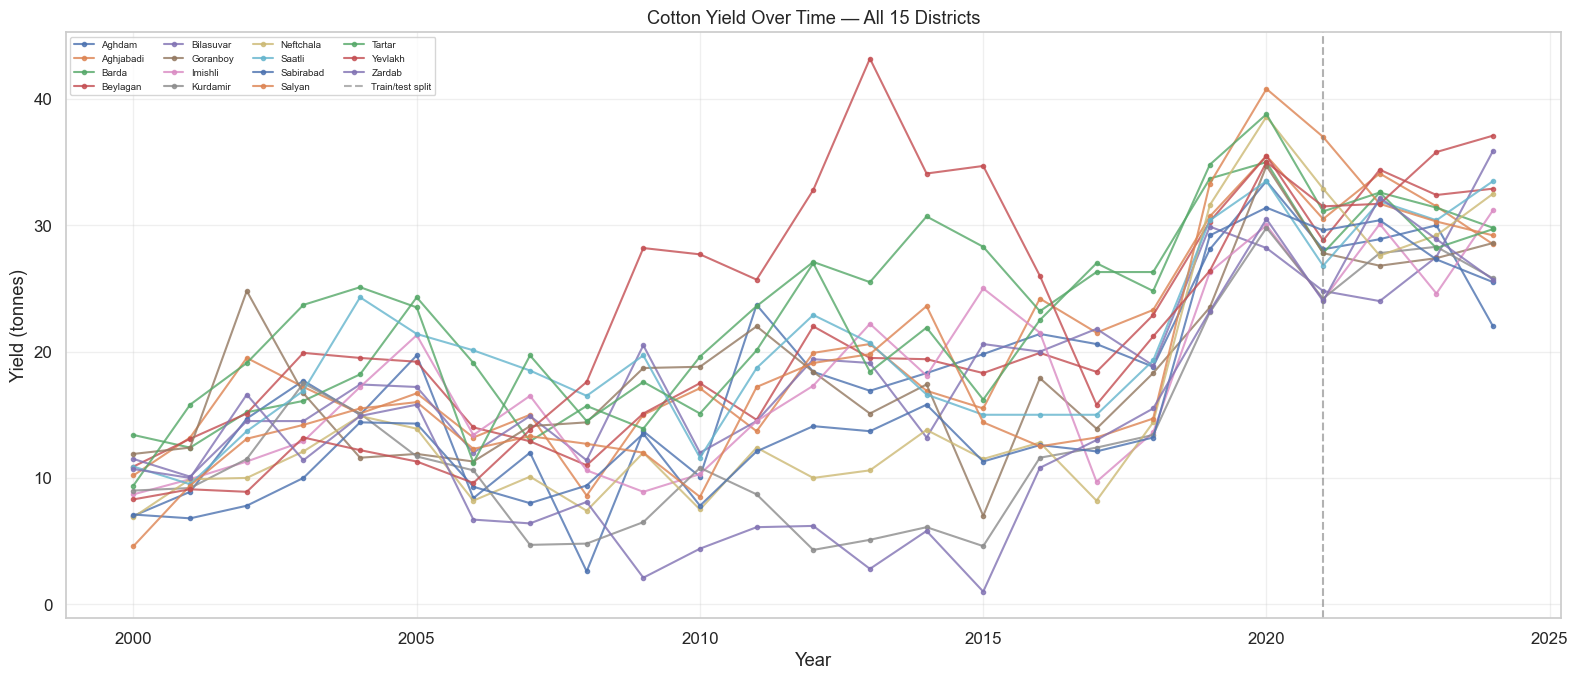

In [4]:
df = con.execute("""
    SELECT region, year, yield_tonnes
    FROM clean_cotton
    ORDER BY region, year
""").df()

fig, ax = plt.subplots(figsize=(16, 7))
for region, grp in df.groupby('region'):
    ax.plot(grp['year'], grp['yield_tonnes'],
            marker='o', markersize=3, linewidth=1.5, alpha=0.8,
            label=region.replace(' district',''))
ax.axvline(2021, color='gray', linestyle='--', alpha=0.6, label='Train/test split')
ax.set_title('Cotton Yield Over Time — All 15 Districts')
ax.set_xlabel('Year')
ax.set_ylabel('Yield (tonnes)')
ax.legend(fontsize=7, ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Average Yield per District (ranked)

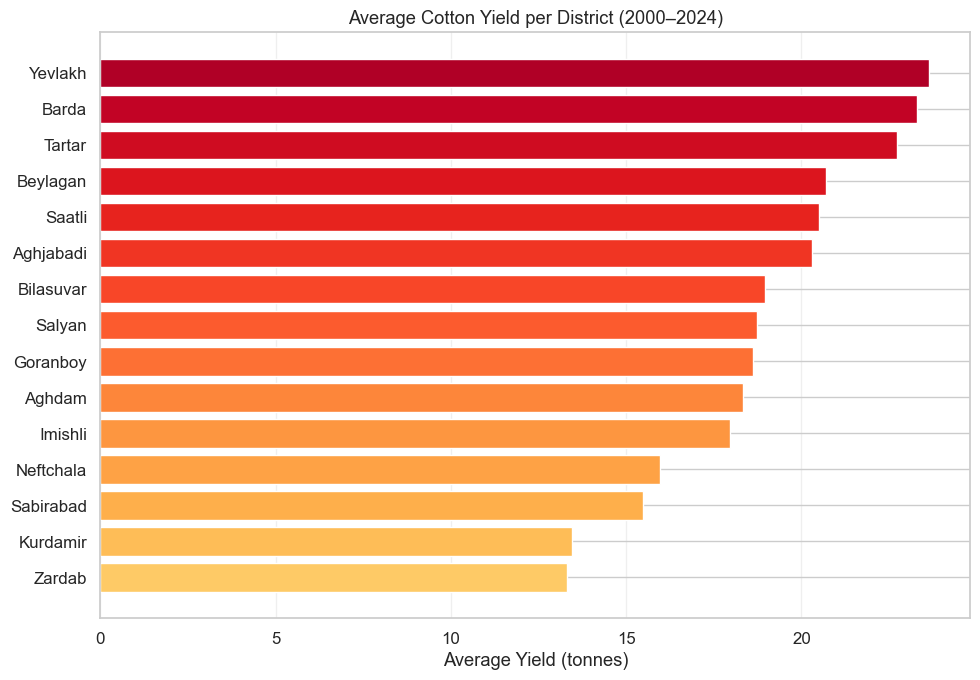

In [5]:
df_avg = df.groupby('region')['yield_tonnes'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(df_avg)))
ax.barh([r.replace(' district','') for r in df_avg.index],
        df_avg.values, color=colors)
ax.set_title('Average Cotton Yield per District (2000–2024)')
ax.set_xlabel('Average Yield (tonnes)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Weather Variable Seasonality

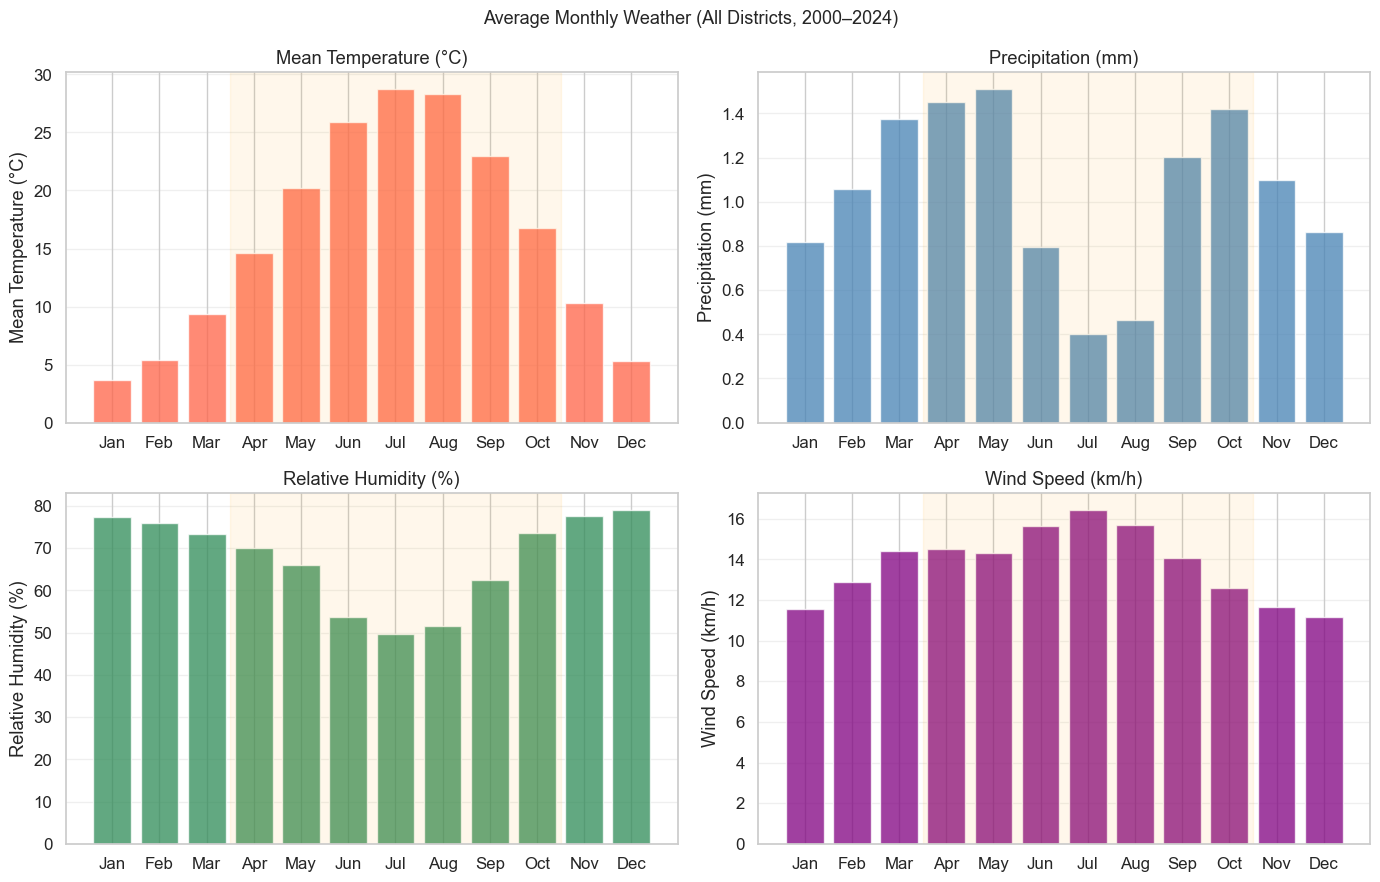

In [6]:
df_w = con.execute("""
    SELECT month,
           AVG(temp_mean)     AS temp_mean,
           AVG(precipitation) AS precipitation,
           AVG(humidity_mean) AS humidity_mean,
           AVG(wind_speed)    AS wind_speed
    FROM clean_weather
    GROUP BY month
    ORDER BY month
""").df()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

for ax, (col, title, color) in zip(axes.flat, [
    ('temp_mean',     'Mean Temperature (°C)',  'tomato'),
    ('precipitation', 'Precipitation (mm)',      'steelblue'),
    ('humidity_mean', 'Relative Humidity (%)',   'seagreen'),
    ('wind_speed',    'Wind Speed (km/h)',        'purple'),
]):
    ax.bar(months, df_w[col], color=color, alpha=0.75)
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.grid(True, axis='y', alpha=0.3)
    # Shade cotton season (Apr–Oct)
    ax.axvspan(2.5, 9.5, alpha=0.08, color='orange', label='Cotton season')

fig.suptitle('Average Monthly Weather (All Districts, 2000–2024)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Feature Correlation with Yield

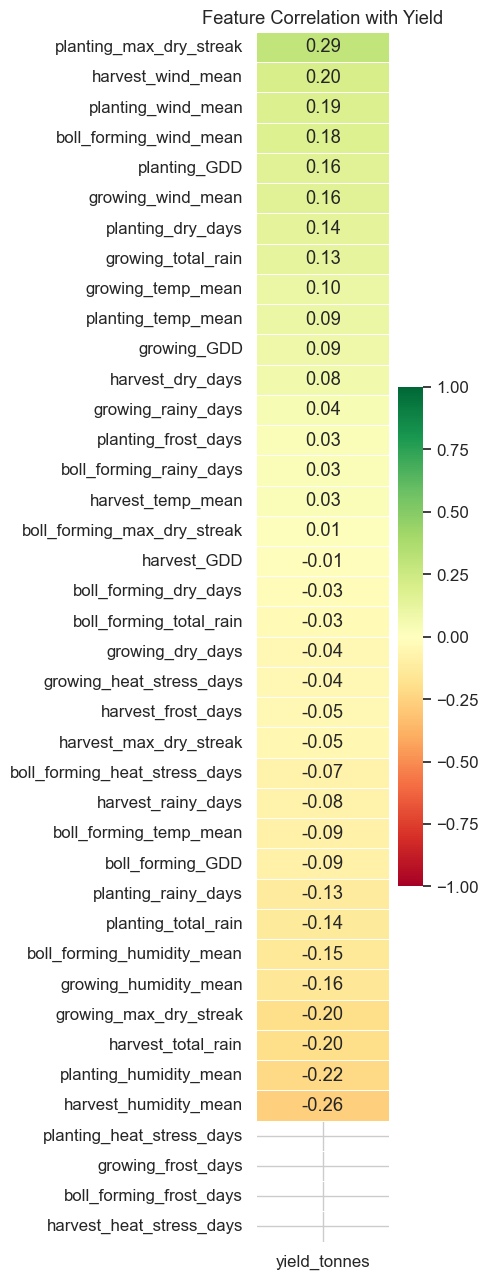

In [7]:
df_feat = con.execute('SELECT * FROM features').df()
feat_cols = [c for c in df_feat.columns
             if any(s in c for s in ['planting_','growing_','boll_','harvest_'])]

corr = (df_feat[feat_cols + ['yield_tonnes']]
        .corr()[['yield_tonnes']]
        .drop('yield_tonnes')
        .sort_values('yield_tonnes', ascending=False))

fig, ax = plt.subplots(figsize=(5, 13))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation with Yield')
plt.tight_layout()
plt.show()

## 5. Risk Scores Over Time

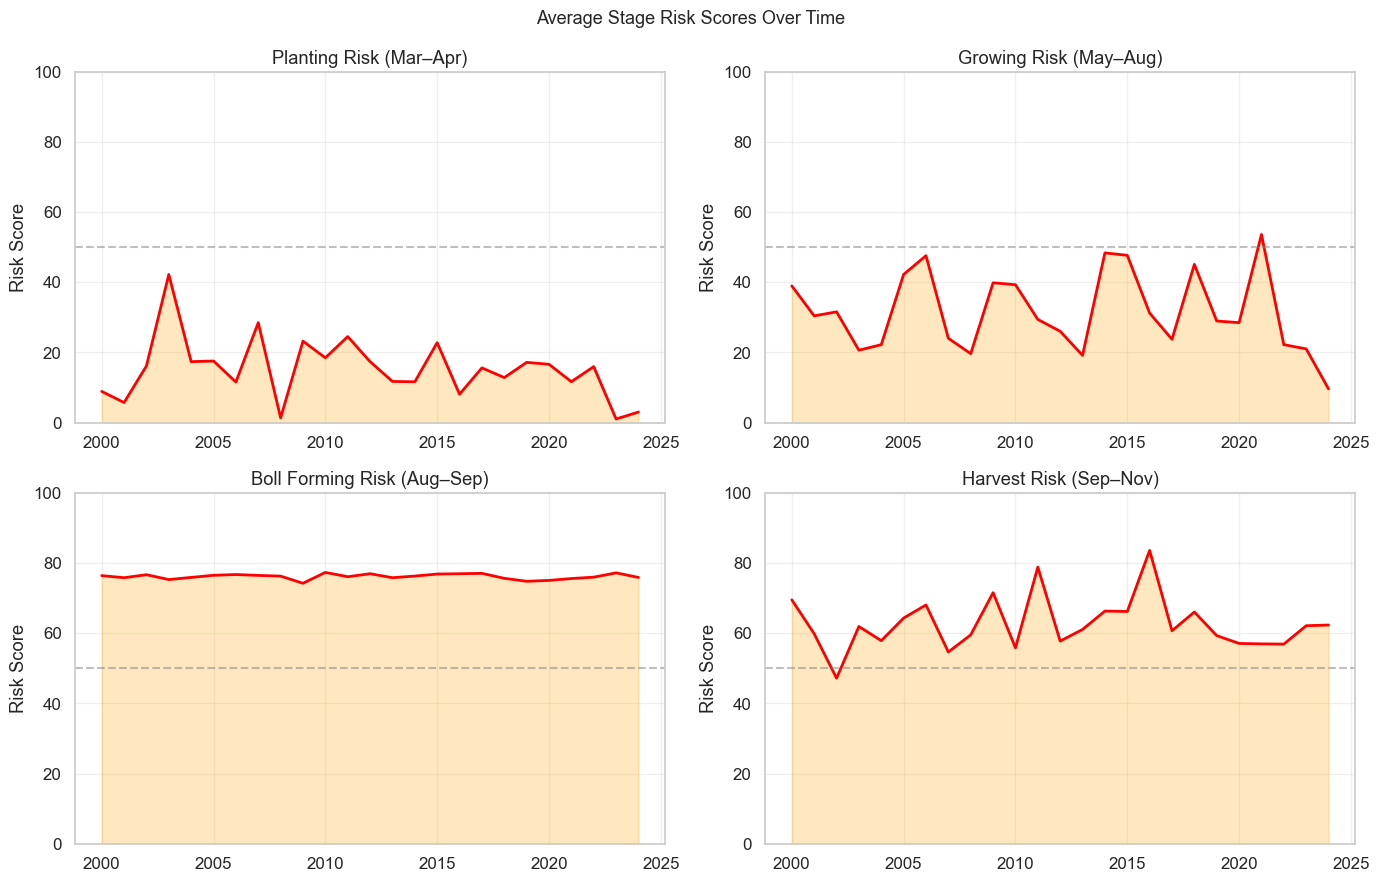

In [8]:
df_risk = con.execute("""
    SELECT year,
           AVG(planting_risk_score) AS planting,
           AVG(growing_risk_score)  AS growing,
           AVG(boll_risk_score)     AS boll,
           AVG(harvest_risk_score)  AS harvest
    FROM features_with_risk
    GROUP BY year ORDER BY year
""").df()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (col, title) in zip(axes.flat, [
    ('planting', 'Planting Risk (Mar–Apr)'),
    ('growing',  'Growing Risk (May–Aug)'),
    ('boll',     'Boll Forming Risk (Aug–Sep)'),
    ('harvest',  'Harvest Risk (Sep–Nov)'),
]):
    ax.fill_between(df_risk['year'], df_risk[col], alpha=0.25, color='orange')
    ax.plot(df_risk['year'], df_risk[col], color='red', linewidth=2)
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(title)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Risk Score')
    ax.grid(True, alpha=0.3)
fig.suptitle('Average Stage Risk Scores Over Time', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Yield Distribution: Safe vs Risky Years

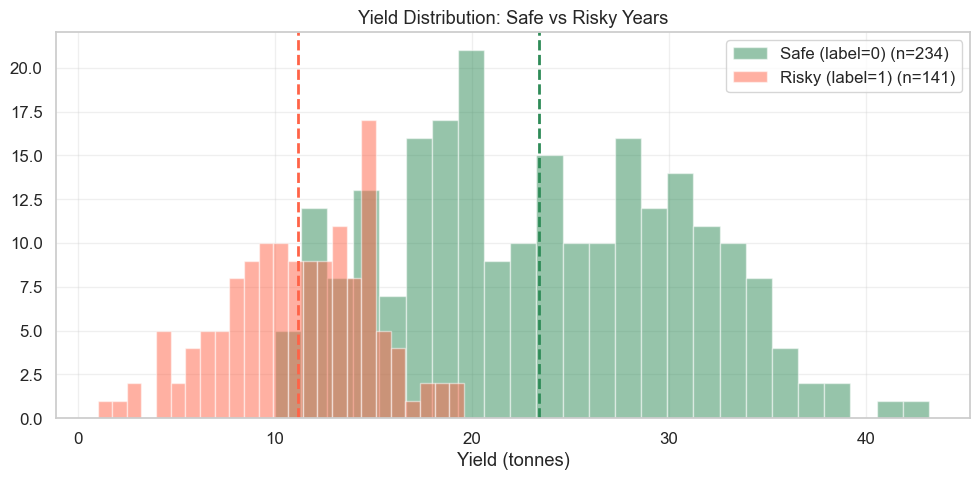

In [9]:
df_r = con.execute('SELECT yield_tonnes, overall_risk_label FROM features_with_risk').df()

fig, ax = plt.subplots(figsize=(10, 5))
for label, color, name in [
    (0, 'seagreen', 'Safe (label=0)'),
    (1, 'tomato',   'Risky (label=1)')
]:
    sub = df_r[df_r['overall_risk_label'] == label]['yield_tonnes']
    ax.hist(sub, bins=25, alpha=0.5, color=color, label=f'{name} (n={len(sub)})')
    ax.axvline(sub.mean(), color=color, linestyle='--', linewidth=2)
ax.set_title('Yield Distribution: Safe vs Risky Years')
ax.set_xlabel('Yield (tonnes)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

con.close()

## Summary
- Yield trends show district baselines dominate (~70% variance) ✓
- Harvest rain and planting temperature most correlated with yield ✓
- Risk scores show meaningful variation across years ✓
- **Next:** `day_07_statistics.ipynb` — statistical analysis